In [ ]:
# Small Matrix 로딩

import pandas as pd
small_matrix = pd.read_csv('/content/small_matrix.csv')
print(small_matrix.shape)
small_matrix.head()

(4676570, 8)


,user_id,video_id,play_duration,video_duration,time,date,timestamp,watch_ratio
0,14,148,4381,6067,2020-07-05 05:27:48.378,20200705.0,1.593898e+09,0.722103
1,14,183,11635,6100,2020-07-05 05:28:00.057,20200705.0,1.593898e+09,1.907377
2,14,3649,22422,10867,2020-07-05 05:29:09.479,20200705.0,1.593898e+09,2.063311
3,14,5262,4479,7908,2020-07-05 05:30:43.285,20200705.0,1.593898e+09,0.566388
4,14,8234,4602,11000,2020-07-05 05:35:43.459,20200705.0,1.593899e+09,0.418364


In [ ]:
# Big matrix 로딩

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

big_matrix = pd.read_csv('/content/big_matrix.csv')
print(big_matrix.shape)
big_matrix.head()

(11292732, 8)


,user_id,video_id,play_duration,video_duration,time,date,timestamp,watch_ratio
0,0,3649,13838,10867,2020-07-05 00:08:23.438,20200705,1.593879e+09,1.273397
1,0,9598,13665,10984,2020-07-05 00:13:41.297,20200705,1.593879e+09,1.244082
2,0,5262,851,7908,2020-07-05 00:16:06.687,20200705,1.593879e+09,0.107613
3,0,1963,862,9590,2020-07-05 00:20:26.792,20200705,1.593880e+09,0.089885
4,0,8234,858,11000,2020-07-05 00:43:05.128,20200705,1.593881e+09,0.078000


전체 영상 수: 10697
상위 10% 영상이 전체 interaction의 40.6% 차지

인기도 상위 5개:
video_id
8145     25033
1037     11175
9485     10077
10174     9393
7508      9004
Name: watch_ratio, dtype: int64

인기도 하위 5개:
video_id
5893     1
5867     1
10214    1
10215    1
3736     1
Name: watch_ratio, dtype: int64


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49692 (\N{HANGUL SYLLABLE SUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lo

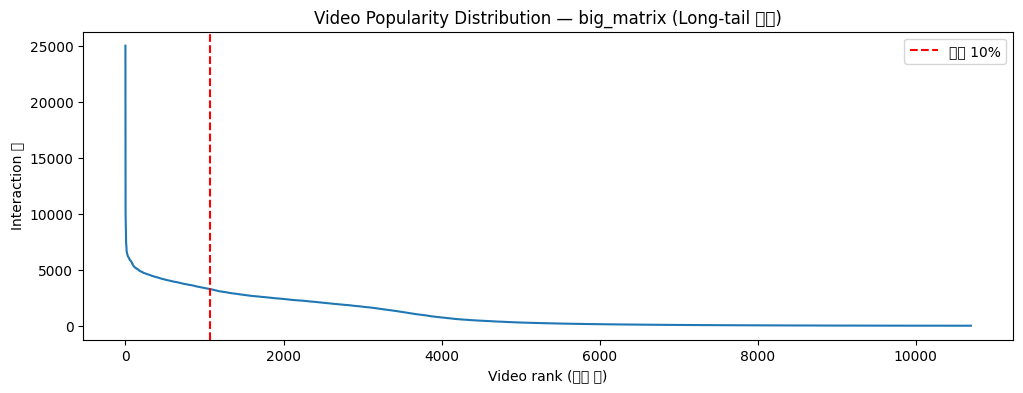

In [ ]:
# video별 interaction 수 계산
popularity = big_matrix.groupby('video_id')['watch_ratio'].count().sort_values(ascending=False)

print(f"전체 영상 수: {len(popularity)}")
print(f"상위 10% 영상이 전체 interaction의 {popularity[:int(len(popularity)*0.1)].sum()/len(big_matrix)*100:.1f}% 차지")
print(f"\n인기도 상위 5개:\n{popularity.head()}")
print(f"\n인기도 하위 5개:\n{popularity.tail()}")

# 시각화 해보기
plt.figure(figsize=(12, 4))
plt.plot(popularity.values)
plt.xlabel('Video rank (인기 순)')
plt.ylabel('Interaction 수')
plt.title('Video Popularity Distribution — big_matrix (Long-tail 확인)')
plt.axvline(x=int(len(popularity)*0.1), color='red', linestyle='--', label='상위 10%')
plt.legend()
plt.show()

In [ ]:
print(f"전체 영상 수: {len(popularity)}")
print(f"상위 10% 영상 수: {int(len(popularity)*0.1)}개")
print(f"상위 10% 영상이 전체 interaction의 {popularity[:int(len(popularity)*0.1)].sum()/len(big_matrix)*100:.1f}% 차지")
print(f"최대 interaction: {popularity.max()}회")
print(f"중앙값 interaction: {popularity.median():.0f}회")
print(f"평균 interaction: {popularity.mean():.1f}회")

전체 영상 수: 10697
상위 10% 영상 수: 1069개
상위 10% 영상이 전체 interaction의 40.6% 차지
최대 interaction: 25033회
중앙값 interaction: 220회
평균 interaction: 1055.7회


인기도 vs 평균 watch_ratio 상관계수: -0.0863


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

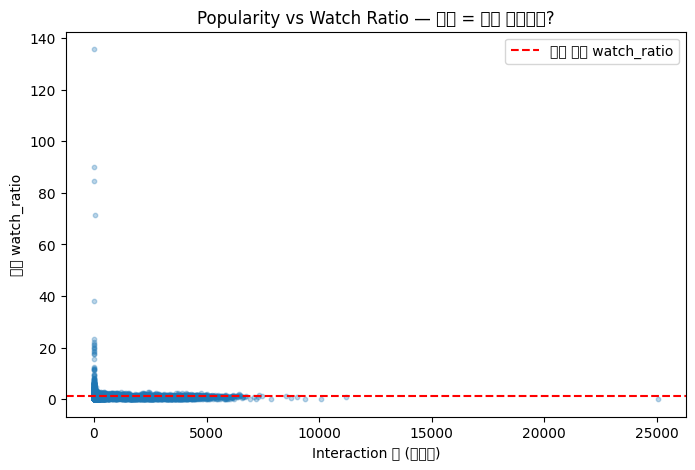

In [ ]:
# video별 평균 watch_ratio + interaction 수 합치기
video_stats = big_matrix.groupby('video_id').agg(
    interaction_count=('watch_ratio', 'count'),
    avg_watch_ratio=('watch_ratio', 'mean')).reset_index()

# 상관계수
corr = video_stats['interaction_count'].corr(video_stats['avg_watch_ratio'])
print(f"인기도 vs 평균 watch_ratio 상관계수: {corr:.4f}")

# 시각화
plt.figure(figsize=(8, 5))
plt.scatter(video_stats['interaction_count'],
            video_stats['avg_watch_ratio'],
            alpha=0.3, s=10)
plt.xlabel('Interaction 수 (인기도)')
plt.ylabel('평균 watch_ratio')
plt.title('Popularity vs Watch Ratio — 인기 = 진짜 선호인가?')
plt.axhline(y=video_stats['avg_watch_ratio'].mean(),
            color='red', linestyle='--', label='전체 평균 watch_ratio')
plt.legend()
plt.show()

In [ ]:
# video별 실제 노출 횟수 계산 (small_matrix 기준)
exposure_count = small_matrix.groupby('video_id')['watch_ratio'].count()
total_users = small_matrix['user_id'].nunique()

# 실제 노출 확률 = 해당 video에 노출된 횟수 / 전체 유저 수
propensity = exposure_count / total_users

print(f"전체 유저 수: {total_users}")
print(f"전체 영상 수: {len(propensity)}")
print(f"\npropensity score 범위: {propensity.min():.4f} ~ {propensity.max():.4f}")
print(f"평균 propensity: {propensity.mean():.4f}")
print(f"\n상위 5개:\n{propensity.sort_values(ascending=False).head()}")
print(f"\n하위 5개:\n{propensity.sort_values().head()}")

# 얘는 상대적 실패로 big matrix로 계산해볼 것임.

전체 유저 수: 1411
전체 영상 수: 3327

propensity score 범위: 0.9320 ~ 1.0000
평균 propensity: 0.9962

상위 5개:
video_id
10436    1.0
10430    1.0
109      1.0
120      1.0
10386    1.0
Name: watch_ratio, dtype: float64

하위 5개:
video_id
784     0.931963
9984    0.931963
5973    0.934089
7083    0.934798
6753    0.935507
Name: watch_ratio, dtype: float64


전체 영상 수: 10697
propensity score 범위: 0.0063 ~ 1.0000
평균 propensity: 0.1536
중앙값 propensity: 0.0937


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


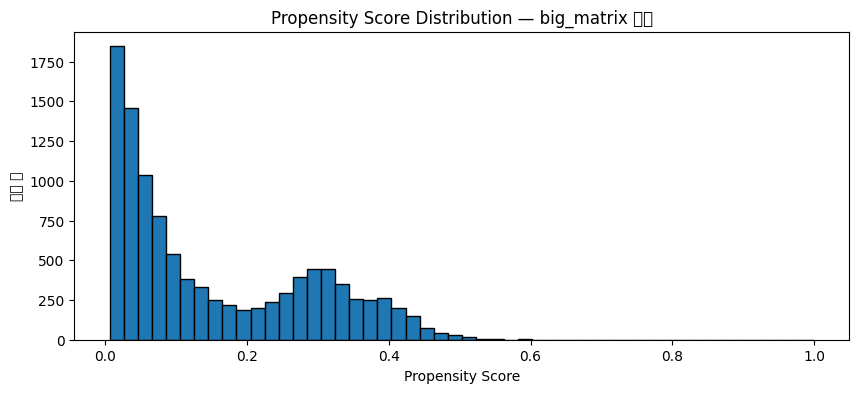

In [ ]:
# big_matrix 기준 propensity score 계산
# 1단계: video별 interaction 수 (이미 계산한 popularity 재활용)
exposure_big = big_matrix.groupby('video_id')['watch_ratio'].count()
total_interactions_big = len(big_matrix)

# 2단계: 정규화 (0~1)
propensity_big = exposure_big / exposure_big.max()

# 3단계: 너무 작은 확률 방지 + 지수 튜닝 (α=0.5)
epsilon = 1e-8
alpha = 0.5
propensity_big = propensity_big.apply(lambda x: max(x, epsilon) ** alpha)

print(f"전체 영상 수: {len(propensity_big)}")
print(f"propensity score 범위: {propensity_big.min():.4f} ~ {propensity_big.max():.4f}")
print(f"평균 propensity: {propensity_big.mean():.4f}")
print(f"중앙값 propensity: {propensity_big.median():.4f}")

# 시각화
plt.figure(figsize=(10, 4))
plt.hist(propensity_big.values, bins=50, edgecolor='black')
plt.xlabel('Propensity Score')
plt.ylabel('영상 수')
plt.title('Propensity Score Distribution — big_matrix 기준')
plt.show()

In [ ]:
# big_matrix_clean 정의
import scipy.sparse as sparse
import numpy as np

big_matrix_clean = big_matrix.dropna(subset=['user_id', 'video_id']).reset_index(drop=True).copy()
exposure_raw = big_matrix_clean.groupby('video_id')['watch_ratio'].count()

print(f"big_matrix_clean shape: {big_matrix_clean.shape}")
print(f"유저 수: {big_matrix_clean['user_id'].nunique()}")
print(f"아이템 수: {big_matrix_clean['video_id'].nunique()}")

big_matrix_clean shape: (11292732, 8)
유저 수: 6464
아이템 수: 10697


In [ ]:
print(f"big_matrix shape: {big_matrix.shape}")
print(f"big_matrix user 수: {big_matrix['user_id'].nunique()}")
print(f"big_matrix item 수: {big_matrix['video_id'].nunique()}")

big_matrix shape: (11292732, 8)
big_matrix user 수: 6464
big_matrix item 수: 10697


In [ ]:
# IPS 가중치 계산
ips_weights = big_matrix_clean['video_id'].map(
    lambda v: 1.0 / propensity_big.get(v, 1.0)
).values
ips_weights = np.clip(ips_weights, 1.0, 50.0)

print(f"IPS 가중치 범위: {ips_weights.min():.4f} ~ {ips_weights.max():.4f}")
print(f"IPS 가중치 평균: {ips_weights.mean():.4f}")
print(f"IPS 가중치 길이: {len(ips_weights)}")

IPS 가중치 범위: 1.0000 ~ 50.0000
IPS 가중치 평균: 3.6302
IPS 가중치 길이: 11292732


In [ ]:
!pip install implicit -q
import pandas as pd
import numpy as np
import scipy.sparse as sparse
import implicit

# category 재정의
user_cat = pd.Categorical(big_matrix_clean['user_id'])
item_cat = pd.Categorical(big_matrix_clean['video_id'])

user_codes = user_cat.codes
item_codes = item_cat.codes
n_users = len(user_cat.categories)
n_items = len(item_cat.categories)

# 원본 ID ↔ code 매핑
user_id2code = {uid: code for uid, code
                in zip(user_cat.categories, range(n_users))}
item_code2id = {code: int(iid)
                for code, iid in enumerate(item_cat.categories)}

# user × item sparse matrix
train_ui = sparse.csr_matrix(
    (np.ones(len(big_matrix_clean)), (user_codes, item_codes)),
    shape=(n_users, n_items)
)
train_ui_ips = sparse.csr_matrix(
    (ips_weights, (user_codes, item_codes)),
    shape=(n_users, n_items)
)

print(f"train_ui shape: {train_ui.shape}")

# Baseline BPR 학습
model_baseline = implicit.bpr.BayesianPersonalizedRanking(
    factors=50, iterations=100, random_state=42
)
model_baseline.fit(train_ui)

# IPS debiased BPR 학습
model_ips = implicit.bpr.BayesianPersonalizedRanking(
    factors=50, iterations=100, random_state=42
)
model_ips.fit(train_ui_ips)

print(f"user_factors: {model_baseline.user_factors.shape}")
print(f"item_factors: {model_baseline.item_factors.shape}")
print("학습 완료!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 46.7 MB/s eta 0:00:00
train_ui shape: (6464, 10697)


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

user_factors: (6464, 51)
item_factors: (10697, 51)
학습 완료!


In [ ]:
# small_matrix 아이템만 후보로 제한
small_matrix_clean = small_matrix.dropna(subset=['user_id', 'video_id'])
small_items = set(small_matrix_clean['video_id'].astype(int).unique())
candidate_item_codes = [
    code for code, iid in item_code2id.items()
    if iid in small_items
]
print(f"추천 후보 아이템 수: {len(candidate_item_codes)}")

# IPS 기반 re-ranking 함수
def get_ips_reranked_recommendations(model, train_mat, user_idx,
                                      item_code2id, propensity_big,
                                      candidate_codes, lam=0.0, N=10, pool=50):
    rec = model.recommend(
        user_idx, train_mat[user_idx],
        N=pool, filter_already_liked_items=True,
        items=candidate_codes
    )
    item_codes_pool = rec[0]
    scores_pool = rec[1]

    reranked = []
    for code, score in zip(item_codes_pool, scores_pool):
        item_id = item_code2id[code]
        prop = propensity_big.get(item_id, 1.0)
        ips_score = score * (1 - lam) + (score / prop) * lam
        reranked.append((code, item_id, score, prop, ips_score))

    reranked.sort(key=lambda x: x[4], reverse=True)
    return reranked[:N]

# λ별 평균 인기도 비교
lambdas = [0.0, 0.3, 0.5, 0.7, 1.0]
avg_pops = []

for lam in lambdas:
    pops = []
    for user_idx in range(n_users):
        recs = get_ips_reranked_recommendations(
            model_baseline, train_ui, user_idx,
            item_code2id, propensity_big,
            candidate_item_codes, lam=lam
        )
        for _, item_id, _, _, _ in recs:
            pops.append(exposure_raw.get(item_id, 0))
    avg_pops.append(np.mean(pops))
    print(f"λ={lam:.1f} → 평균 인기도: {np.mean(pops):.2f}")

추천 후보 아이템 수: 3327
λ=0.0 → 평균 인기도: 3322.35
λ=0.3 → 평균 인기도: 2424.23
λ=0.5 → 평균 인기도: 2225.26
λ=0.7 → 평균 인기도: 2114.70
λ=1.0 → 평균 인기도: 2018.82


/tmp/ipykernel_3406/3140232403.py:93: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3406/3140232403.py:93: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3406/3140232403.py:93: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3406/3140232403.py:93: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3406/3140232403.py:93: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3406/3140232403.py:93: UserWarning: Glyph 52380 (\N{HANGUL SYLLABLE CEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3406/3140232403.py:93: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from font(s) DejaVu Sans.
  plt.tight_la

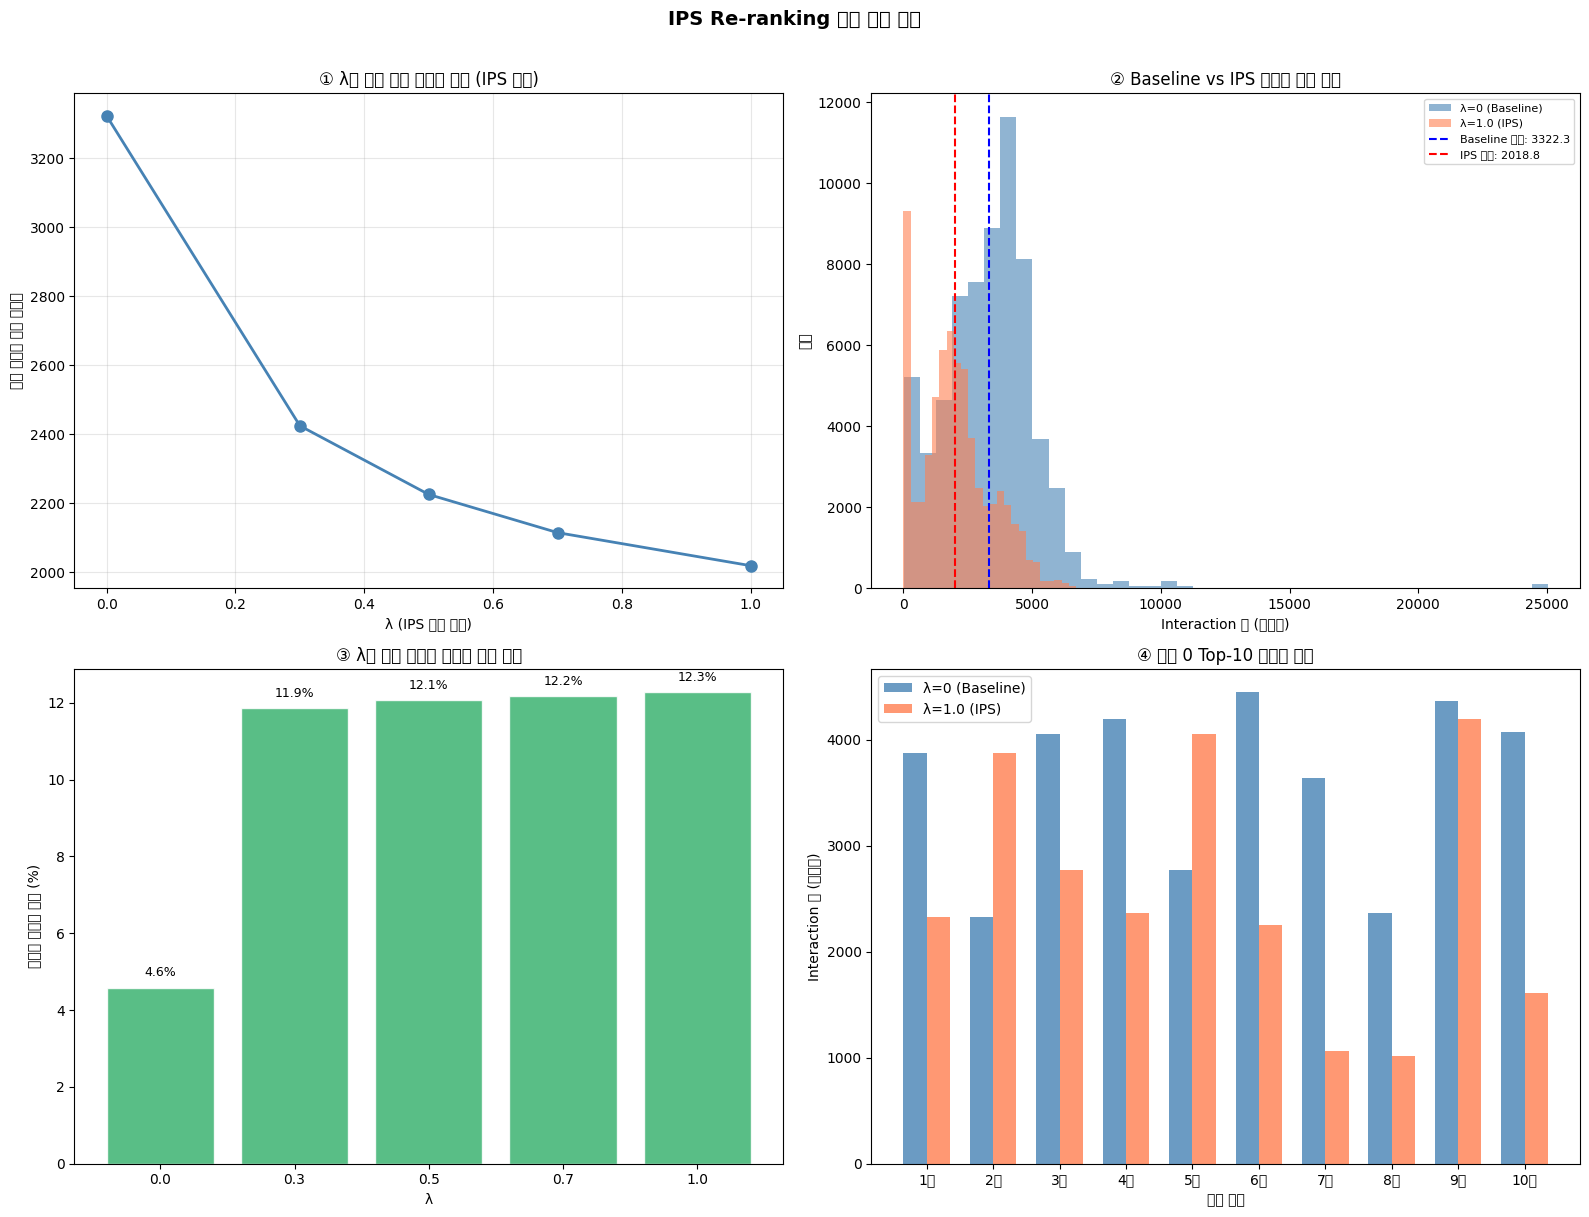

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. λ별 평균 인기도 변화
axes[0, 0].plot(lambdas, avg_pops, 'o-', color='steelblue',
                linewidth=2, markersize=8)
axes[0, 0].set_xlabel('λ (IPS 보정 강도)')
axes[0, 0].set_ylabel('추천 아이템 평균 인기도')
axes[0, 0].set_title('① λ에 따른 평균 인기도 변화 (IPS 기반)')
axes[0, 0].grid(True, alpha=0.3)

# 2. λ=0 vs λ=1.0 분포 비교
pop_lam0, pop_lam1 = [], []
for user_idx in range(n_users):
    r0 = get_ips_reranked_recommendations(
        model_baseline, train_ui, user_idx,
        item_code2id, propensity_big,
        candidate_item_codes, lam=0.0)
    r1 = get_ips_reranked_recommendations(
        model_baseline, train_ui, user_idx,
        item_code2id, propensity_big,
        candidate_item_codes, lam=1.0)
    for _, item_id, _, _, _ in r0:
        pop_lam0.append(exposure_raw.get(item_id, 0))
    for _, item_id, _, _, _ in r1:
        pop_lam1.append(exposure_raw.get(item_id, 0))

axes[0, 1].hist(pop_lam0, bins=40, alpha=0.6,
                color='steelblue', label='λ=0 (Baseline)')
axes[0, 1].hist(pop_lam1, bins=40, alpha=0.6,
                color='coral', label='λ=1.0 (IPS)')
axes[0, 1].axvline(np.mean(pop_lam0), color='blue', linestyle='--',
                   label=f'Baseline 평균: {np.mean(pop_lam0):.1f}')
axes[0, 1].axvline(np.mean(pop_lam1), color='red', linestyle='--',
                   label=f'IPS 평균: {np.mean(pop_lam1):.1f}')
axes[0, 1].set_xlabel('Interaction 수 (인기도)')
axes[0, 1].set_ylabel('빈도')
axes[0, 1].set_title('② Baseline vs IPS 인기도 분포 비교')
axes[0, 1].legend(fontsize=8)

# 3. 롱테일 비율
longtail_threshold = exposure_raw.median()
longtail_ratios = []
for lam in lambdas:
    lt_count, total = 0, 0
    for user_idx in range(n_users):
        recs = get_ips_reranked_recommendations(
            model_baseline, train_ui, user_idx,
            item_code2id, propensity_big,
            candidate_item_codes, lam=lam)
        for _, item_id, _, _, _ in recs:
            if exposure_raw.get(item_id, 0) <= longtail_threshold:
                lt_count += 1
            total += 1
    longtail_ratios.append(lt_count / total * 100)

axes[1, 0].bar([str(l) for l in lambdas], longtail_ratios,
               color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1, 0].set_xlabel('λ')
axes[1, 0].set_ylabel('롱테일 아이템 비율 (%)')
axes[1, 0].set_title('③ λ에 따른 롱테일 아이템 추천 비율')
for i, v in enumerate(longtail_ratios):
    axes[1, 0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

# 4. 유저 샘플 Top-10 비교
user_idx_sample = 0
r0_s = get_ips_reranked_recommendations(
    model_baseline, train_ui, user_idx_sample,
    item_code2id, propensity_big,
    candidate_item_codes, lam=0.0)
r1_s = get_ips_reranked_recommendations(
    model_baseline, train_ui, user_idx_sample,
    item_code2id, propensity_big,
    candidate_item_codes, lam=1.0)

x = np.arange(10)
width = 0.35
pops_base = [exposure_raw.get(item_id, 0) for _, item_id, _, _, _ in r0_s]
pops_ips  = [exposure_raw.get(item_id, 0) for _, item_id, _, _, _ in r1_s]

axes[1, 1].bar(x - width/2, pops_base, width,
               label='λ=0 (Baseline)', color='steelblue', alpha=0.8)
axes[1, 1].bar(x + width/2, pops_ips, width,
               label='λ=1.0 (IPS)', color='coral', alpha=0.8)
axes[1, 1].set_xlabel('추천 순위')
axes[1, 1].set_ylabel('Interaction 수 (인기도)')
axes[1, 1].set_title(f'④ 유저 {user_idx_sample} Top-10 인기도 비교')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels([f'{i+1}위' for i in range(10)])
axes[1, 1].legend()

plt.suptitle('IPS Re-ranking 편향 보정 분석', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
import pickle
import numpy as np

# 모델과 데이터 저장
with open('model_data.pkl', 'wb') as f:
    pickle.dump({
        'model_baseline': model_baseline,
        'propensity_big': propensity_big,
        'exposure_raw': exposure_raw,
        'item_code2id': item_code2id,
        'user_id2code': user_id2code,
        'candidate_item_codes': candidate_item_codes,
        'n_users': n_users,
        'n_items': n_items
    }, f)

print("저장 완료!")

저장 완료!


In [ ]:
##

import pandas as pd
import ast

item_categories = pd.read_csv('/content/item_categories.csv')

multi_cat = item_categories['feat'].apply(
    lambda x: len(ast.literal_eval(x)) if isinstance(x, str) else 1
)
print(multi_cat.value_counts())
print(f"\n카테고리 2개 이상 아이템: {(multi_cat > 1).sum()}개 ({(multi_cat > 1).mean()*100:.1f}%)")

feat
1    8970
2    1562
3     185
4      11
Name: count, dtype: int64

카테고리 2개 이상 아이템: 1758개 (16.4%)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# 모델 구글 드라이브에 저장
import pickle
with open('/content/drive/MyDrive/model_data.pkl', 'wb') as f:
    pickle.dump({
        'model_baseline': model_baseline,
        'model_ips': model_ips,
        'train_ui': train_ui,
        'train_ui_ips': train_ui_ips,
        'propensity_big': propensity_big,
        'exposure_raw': exposure_raw,
        'item_code2id': item_code2id,
        'user_id2code': user_id2code,
        'candidate_item_codes': candidate_item_codes,
        'n_users': n_users,
        'n_items': n_items
    }, f)
print("드라이브 저장 완료!")

Mounted at /content/drive
드라이브 저장 완료!


In [ ]:
# 세션 종료시 여기서부터
!pip install implicit -q

from google.colab import drive
drive.mount('/content/drive')

import pickle
import pandas as pd
import numpy as np
import scipy.sparse as sparse
import implicit

# 드라이브에서 모델 불러오기
with open('/content/drive/MyDrive/model_data.pkl', 'rb') as f:
    data = pickle.load(f)

model_baseline = data['model_baseline']
model_ips      = data['model_ips']
train_ui       = data['train_ui']
train_ui_ips   = data['train_ui_ips']
propensity_big = data['propensity_big']
exposure_raw   = data['exposure_raw']
item_code2id   = data['item_code2id']
user_id2code   = data['user_id2code']
candidate_item_codes = data['candidate_item_codes']
n_users        = data['n_users']
n_items        = data['n_items']

small_matrix = pd.read_csv('/content/small_matrix.csv')
big_matrix   = pd.read_csv('/content/big_matrix.csv')

print("불러오기 완료!")
print(f"n_users: {n_users}, n_items: {n_items}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
불러오기 완료!
n_users: 6464, n_items: 10697


In [ ]:
'''



섹터 분






'''

In [ ]:
### 밑은 더블 머신 러닝 트랙, 위와 병렬로 수행함 ###

In [ ]:
# 두 파일 로드 & X(공변량) 구조 확인
user_features = pd.read_csv('/content/user_features.csv')
item_categories = pd.read_csv('/content/item_categories.csv')

print("=== user_features ===")
print(f"shape: {user_features.shape}")
print(user_features.head(3))

print("\n=== item_categories ===")
print(f"shape: {item_categories.shape}")
print(item_categories.head(3))

=== user_features ===
shape: (7176, 31)
   user_id user_active_degree  is_lowactive_period  is_live_streamer  \
0        0        high_active                    0                 0   
1        1        full_active                    0                 0   
2        2        full_active                    0                 0   

   is_video_author  follow_user_num follow_user_num_range  fans_user_num  \
0                0                5                (0,10]              0   
1                0              386             (250,500]              4   
2                0               27               (10,50]              0   

  fans_user_num_range  friend_user_num  ... onehot_feat8  onehot_feat9  \
0                   0                0  ...          184             6   
1              [1,10)                2  ...          186             6   
2                   0                0  ...           51             2   

  onehot_feat10  onehot_feat11  onehot_feat12  onehot_feat13  onehot_

In [ ]:
# 1. big_matrix와 user_features 병합
merged = big_matrix.merge(user_features, on='user_id', how='inner')

# 2. item_categories feat 파싱 (첫 번째 카테고리만 사용)
import ast
item_categories['feat_parsed'] = item_categories['feat'].apply(
    lambda x: ast.literal_eval(x)[0] if isinstance(x, str) else x[0])

# 3. merged에 item_categories 병합
merged = merged.merge(
    item_categories[['video_id', 'feat_parsed']],
    on='video_id',
    how='inner')

print(f"병합 후 shape: {merged.shape}")
print(merged.head(3))

'''
DML은 공변량 X가 풍부할수록 교란변수 통제가 정교해진다. KuaiRec은 유저 특성(user_features)과 아이템 카테고리(item_categories)를 별도 파일로 제공한다. 이를 big_matrix(관측 로그)와 병합해 하나의 분석 테이블을 구성한다.
user_id 기준 inner join → 유저 특성이 없는 행 제거 (데이터 정합성 확보)
item_categories의 feat 컬럼은 리스트 형태([8], [27, 9])로 저장돼 있어, 첫 번째 카테고리만 파싱해 사용
첫 번째 카테고리만 쓰는 이유: 아이템당 여러 카테고리가 있을 수 있으나, 단일 수치 특성으로 단순화해 모델 입력으로 사용
'''

병합 후 shape: (7999797, 39)
   user_id  video_id  play_duration  video_duration                     time  \
0        0      3649          13838           10867  2020-07-05 00:08:23.438   
1        0      9598          13665           10984  2020-07-05 00:13:41.297   
2        0      5262            851            7908  2020-07-05 00:16:06.687   

       date     timestamp  watch_ratio user_active_degree  \
0  20200705  1.593879e+09     1.273397        high_active   
1  20200705  1.593879e+09     1.244082        high_active   
2  20200705  1.593879e+09     0.107613        high_active   

   is_lowactive_period  ...  onehot_feat9  onehot_feat10  onehot_feat11  \
0                    0  ...             6              3              0   
1                    0  ...             6              3              0   
2                    0  ...             6              3              0   

  onehot_feat12  onehot_feat13 onehot_feat14  onehot_feat15 onehot_feat16  \
0           0.0            0.0

'\nDML은 공변량 X가 풍부할수록 교란변수 통제가 정교해진다. KuaiRec은 유저 특성(user_features)과 아이템 카테고리(item_categories)를 별도 파일로 제공한다. 이를 big_matrix(관측 로그)와 병합해 하나의 분석 테이블을 구성한다.\nuser_id 기준 inner join → 유저 특성이 없는 행 제거 (데이터 정합성 확보)\nitem_categories의 feat 컬럼은 리스트 형태([8], [27, 9])로 저장돼 있어, 첫 번째 카테고리만 파싱해 사용\n첫 번째 카테고리만 쓰는 이유: 아이템당 여러 카테고리가 있을 수 있으나, 단일 수치 특성으로 단순화해 모델 입력으로 사용\n'

In [ ]:
from sklearn.preprocessing import LabelEncoder

X_df = merged[[
    'user_active_degree',
    'is_lowactive_period', 'is_live_streamer', 'is_video_author',
    'follow_user_num', 'fans_user_num', 'friend_user_num',
    'onehot_feat8', 'onehot_feat9', 'onehot_feat10',
    'onehot_feat11', 'onehot_feat12', 'onehot_feat13',
    'onehot_feat14', 'onehot_feat15', 'onehot_feat16',
    'onehot_feat17', 'feat_parsed']].copy()

le = LabelEncoder()

X_df['user_active_degree'] = le.fit_transform(
    X_df['user_active_degree'].astype(str))

X_df = X_df.fillna(0)

print(f"X_df shape: {X_df.shape}")

'''
DML에서 X는 T와 Y 양쪽에 영향을 주는 교란변수다. Y=θT+g(X)+ε에서 g(X)와 m(X)를 ML로 추정하려면 X가 수치형이어야 한다.

18개 공변량 선택 이유:

유저 행동 특성 (follow_user_num, fans_user_num 등): 유저의 플랫폼 활동 패턴이 노출(T)과 시청(Y) 모두에 영향
onehot_feat8~17: KuaiRec이 제공하는 익명화된 유저 특성 (개인정보 보호 처리됨)
feat_parsed: 아이템 카테고리 — 카테고리별 노출 편향이 다를 수 있음


user_active_degree LabelEncoder 이유:

high_active, full_active 등 문자열 범주형 → 수치형으로 변환 필요
단, LabelEncoder는 순서 관계를 임의로 부여하므로, 추후 OneHotEncoding으로 개선 가능


fillna(0) 이유:

결측치가 있으면 RandomForest 학습 불가
0으로 채우는 건 "해당 특성 없음"으로 해석
'''

X_df shape: (7999797, 18)


'\nDML에서 X는 T와 Y 양쪽에 영향을 주는 교란변수다. Y=θT+g(X)+ε에서 g(X)와 m(X)를 ML로 추정하려면 X가 수치형이어야 한다.\n\n18개 공변량 선택 이유:\n\n유저 행동 특성 (follow_user_num, fans_user_num 등): 유저의 플랫폼 활동 패턴이 노출(T)과 시청(Y) 모두에 영향\nonehot_feat8~17: KuaiRec이 제공하는 익명화된 유저 특성 (개인정보 보호 처리됨)\nfeat_parsed: 아이템 카테고리 — 카테고리별 노출 편향이 다를 수 있음\n\n\nuser_active_degree LabelEncoder 이유:\n\nhigh_active, full_active 등 문자열 범주형 → 수치형으로 변환 필요\n단, LabelEncoder는 순서 관계를 임의로 부여하므로, 추후 OneHotEncoding으로 개선 가능\n\n\nfillna(0) 이유:\n\n결측치가 있으면 RandomForest 학습 불가\n0으로 채우는 건 "해당 특성 없음"으로 해석\n'

In [ ]:
# merged shape 확인
print(f"merged shape: {merged.shape}")

merged shape: (7999797, 39)


In [ ]:
# 샘플링 (1% = 약 8만행) — 메모리 절약
merged_sample = merged.sample(frac=0.01, random_state=42).reset_index(drop=True)
print(f"샘플 크기: {merged_sample.shape}")

Y = merged_sample['watch_ratio'].values

# T: 상위 10% 인기 아이템 = 1
item_exposure = big_matrix.groupby('video_id')['watch_ratio'].count()
top10_threshold = item_exposure.quantile(0.9)
T = merged_sample['video_id'].map(
    lambda v: 1 if item_exposure.get(v, 0) >= top10_threshold else 0
).values

from sklearn.preprocessing import LabelEncoder
X_df_sample = merged_sample[[
    'user_active_degree',
    'is_lowactive_period', 'is_live_streamer', 'is_video_author',
    'follow_user_num', 'fans_user_num', 'friend_user_num',
    'onehot_feat8', 'onehot_feat9', 'onehot_feat10',
    'onehot_feat11', 'onehot_feat12', 'onehot_feat13',
    'onehot_feat14', 'onehot_feat15', 'onehot_feat16',
    'onehot_feat17', 'feat_parsed'
]].copy()

le = LabelEncoder()
X_df_sample['user_active_degree'] = le.fit_transform(
    X_df_sample['user_active_degree'].astype(str))
X_df_sample = X_df_sample.fillna(0)
X = X_df_sample.values

print(f"Y shape: {Y.shape}")
print(f"T shape: {T.shape}, T=1 비율: {T.mean():.4f}")
print(f"X shape: {X.shape}")

샘플 크기: (79998, 39)
Y shape: (79998,)
T shape: (79998,), T=1 비율: 0.4047
X shape: (79998, 18)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict

# DML 1단계 — ML로 X → T 예측 (cross-fitting K=5)
model_t = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1)

T_pred = cross_val_predict(
    model_t, X, T,
    cv=5,
    method='predict_proba')[:, 1]  # T=1 확률

# 잔차 계산 ê_T = T - T_pred
T_resid = T - T_pred

print(f"1단계 완료!")
print(f"T_pred 범위: {T_pred.min():.4f} ~ {T_pred.max():.4f}")
print(f"T_resid 평균: {T_resid.mean():.4f}")
print(f"T_resid 표준편차: {T_resid.std():.4f}")

1단계 완료!
T_pred 범위: 0.3081 ~ 0.5592
T_resid 평균: -0.0001
T_resid 표준편차: 0.4872


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_predict

# DML 2단계 — ML로 X → Y 예측 (cross-fitting K=5)
model_y = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1)

Y_pred = cross_val_predict(
    model_y, X, Y,
    cv=5)

# 잔차 계산 ê_Y = Y - Y_pred
Y_resid = Y - Y_pred

print(f"2단계 완료!")
print(f"Y_pred 범위: {Y_pred.min():.4f} ~ {Y_pred.max():.4f}")
print(f"Y_resid 평균: {Y_resid.mean():.4f}")
print(f"Y_resid 표준편차: {Y_resid.std():.4f}")

2단계 완료!
Y_pred 범위: 0.2666 ~ 8.5552
Y_resid 평균: -0.0004
Y_resid 표준편차: 1.6904


In [ ]:
import statsmodels.api as sm

# DML 3단계 — 잔차끼리 회귀 → θ 추정
T_resid_const = sm.add_constant(T_resid)
ols_model = sm.OLS(Y_resid, T_resid_const)
result = ols_model.fit()

theta = result.params[1]
conf_int = result.conf_int()[1]  # iloc → 인덱싱으로 수정
p_value = result.pvalues[1]

print(f"=" * 45)
print(f"DML 3단계 — 인과효과 θ 추정 결과")
print(f"=" * 45)
print(f"θ (인과효과 추정치): {theta:.4f}")
print(f"95% 신뢰구간: [{conf_int[0]:.4f}, {conf_int[1]:.4f}]")
print(f"p-value: {p_value:.4f}")
print(f"=" * 45)

if p_value < 0.05:
    print(f"→ 통계적으로 유의미한 인과효과 존재")
    if theta > 0:
        print(f"→ 인기 아이템 배정 시 watch_ratio {theta:.4f} 증가")
    else:
        print(f"→ 인기 아이템 배정 시 watch_ratio {abs(theta):.4f} 감소")
else:
    print(f"→ 통계적으로 유의미하지 않음")

DML 3단계 — 인과효과 θ 추정 결과
θ (인과효과 추정치): -0.0384
95% 신뢰구간: [-0.0624, -0.0143]
p-value: 0.0018
→ 통계적으로 유의미한 인과효과 존재
→ 인기 아이템 배정 시 watch_ratio 0.0384 감소


In [ ]:
# DML 결과 드라이브에 추가 저장
import pickle
from google.colab import drive
drive.mount('/content/drive')

with open('/content/drive/MyDrive/dml_results.pkl', 'wb') as f:
    pickle.dump({
        'theta': theta,
        'conf_int': conf_int,
        'p_value': p_value,
        'T_resid': T_resid,
        'Y_resid': Y_resid,
        'T_pred': T_pred,
        'Y': Y,
        'T': T
    }, f)

print("DML 결과 저장 완료!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DML 결과 저장 완료!


In [ ]:
# 이제 vscode로 가서 streamlit 실행하자.